# Selection, Not Generation

**Can a judgment model raise relation recall over joint decoding, given the same entities?**

[Notebook 10](10_typesafe_system_one.ipynb) ends on a line worth taking literally: *candidate generation
and judgment are different jobs.* TypeSafe's System One model cannot find an edge — it has no spans and
nothing to anchor — and the recall ceiling there stayed exactly where GLiNER left it, at 0.404. But the
model can **select**. Given two mentions the extractor already found, and the short list of relations the
ontology permits between their types, one `Choice` picks the relation the document states — or `none`.

So this notebook enumerates every legal, co-occurring pair of GLiNER's own mentions in code, asks one
question per pair, and scores the result against the same 47 gold triples as every other notebook in the
repo. Nothing is generated. The candidates are the extractor's, the answer set is the ontology's, and the
model only chooses.

| | who does it | how |
|---|---|---|
| **entities** | GLiNER2.5 | joint decoding, unchanged |
| **candidate pairs** | code | ordered pairs within a paragraph whose types the ontology permits |
| **the relation** | TypeSafe `Choice` | one question per pair, criteria = the ontology's relation descriptions + `none` |
| **assertion** | TypeSafe `Choice` + `Noul` | the gate from notebook 10, applied to the selected edges |

Three questions get measured answers: whether selection finds relations joint decoding missed, what
that costs against the joint decoder's zero, and whether widening the candidate window from paragraph to
document buys recall or only buys requests.

Needs `TYPESAFE_API_KEY`, or the cached responses in `output/typesafe_cache/`.

## 0. Setup

In [1]:
import os, sys, time, json, math, warnings
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
warnings.filterwarnings("ignore")
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import msgspec
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.width", 210)
pd.set_option("display.max_colwidth", 46)

import kgx
import kgx.typesafe as kts
from kgx.evaluate import score_triples, graph_triples, comparison_table, MatchPolicy
from kgx.data.documents import DOCUMENTS, ALIAS_GROUPS, GOLD_DOC_FACTS
from kgx.extract import DocGraph, Edge

MATCH = MatchPolicy(normalize_names=True, use_aliases=True)
ONTO = kgx.BUSINESS_NEWS

ts = kts.CachedTypeSafe(cache_dir=ROOT / "output" / "typesafe_cache")
print(ts)
if not ts.available:
    print("TYPESAFE_API_KEY is not set -- replaying from cache; anything new will raise.")

def show(obj):
    print(json.dumps(json.loads(msgspec.json.encode(obj)), indent=2, ensure_ascii=False))

CachedTypeSafe(model='jev-latest', cache_dir='../output/typesafe_cache', key=unset)
TYPESAFE_API_KEY is not set -- replaying from cache; anything new will raise.


In [2]:
t0 = time.perf_counter()
extractor = kgx.GlinerExtractor()
graphs = extractor.extract_batch(DOCUMENTS, ONTO)
gliner_s = time.perf_counter() - t0
mentions = [m for g in graphs for m in g.mentions]

resolver = kgx.EntityResolver().learn_aliases(d["text"] for d in DOCUMENTS)
resolution = resolver.resolve(mentions)

def score(doc_graphs, label):
    kg = kgx.build_graph(doc_graphs, resolution, ONTO)
    tri = graph_triples(kg)
    return score_triples(tri, GOLD_DOC_FACTS, policy=MATCH, aliases=ALIAS_GROUPS), tri

base_score, base_tri = score(graphs, "gliner")
print(f"{len(mentions)} mentions, {sum(len(g.edges) for g in graphs)} edges in {gliner_s:.1f}s")
print(f"GLiNER2.5 baseline, same resolution as notebook 10 §2.4: "
      f"P {base_score.precision:.3f}  R {base_score.recall:.3f}  F1 {base_score.f1:.3f}")

214 mentions, 170 edges in 14.7s
GLiNER2.5 baseline, same resolution as notebook 10 §2.4: P 0.279  R 0.404  F1 0.330


---

## 1. The candidates, and the question

The ontology is the answer set. `BUSINESS_NEWS` has 15 relations with typed endpoints, which compile to 43
legal `(head_type, tail_type)` combinations. For any pair of mentions, the legal relations between their
types are the criteria, `none` is always added, and direction is stated — the reverse pair is a separate
question, because `supplies` runs one way and `subsidiary_of` the other.

In [3]:
legal = kts.legal_relations(ONTO)
print(f"{len(ONTO.relations)} relations -> {len(legal)} legal (head_type, tail_type) combinations")
print(f"most relations for one combination: {max(len(v) for v in legal.values())} "
      f"({[k for k, v in legal.items() if len(v) == max(len(v) for v in legal.values())][0]})\n")

print("one question, for a company -> company pair:\n")
show(kts.relation_questions("Northwind Logistics", "Cascade Freight Systems", legal[("company", "company")]))

15 relations -> 43 legal (head_type, tail_type) combinations
most relations for one combination: 6 (('company', 'company'))

one question, for a company -> company pair:

{
  "relation": {
    "type": "choice",
    "criteria": {
      "subsidiary_of": "The head company is owned or controlled by the tail company.",
      "acquires": "The head company is buying or has bought the tail.",
      "has_stake_in": "The head holds an ownership interest in the tail.",
      "supplies": "The head provides goods or inputs to the tail company.",
      "partners_with": "A stated partnership, alliance, or joint venture.",
      "competes_with": "The two companies are stated rivals in a market.",
      "none": "The document does not relate these two things in any of the ways listed, or relates them only in the opposite direction."
    },
    "instructions": "In `document`, which of these relationships does the text state or discuss from “Northwind Logistics” to “Cascade Freight Systems”, in that direc

How many candidates there are depends on how close two mentions must be to count as a pair. Three
scopes, from pessimistic to generous. Which one is the fair comparison depends on a fact worth measuring
rather than assuming: how many of GLiNER's own edges connect mentions in *different* paragraphs. If joint
decoding routinely reaches across a paragraph break, a selector confined to paragraphs is playing with a
handicap that has nothing to do with judgment.

In [4]:
budget = []
for scope in ("sentence", "paragraph", "document"):
    n = sum(len(kts.candidate_pairs(g, ONTO, scope=scope)) for g in graphs)
    budget.append({"scope": scope, "candidate pairs": n,
                   "requests @ 24 questions": sum(math.ceil(len(kts.candidate_pairs(g, ONTO, scope=scope)) / 24)
                                                 for g in graphs)})
display(pd.DataFrame(budget).set_index("scope"))

def within_paragraph(g, e):
    h, t = g.mention(e.head), g.mention(e.tail)
    lo, hi = min(h.start, t.start), max(h.end, t.end)
    return "\n\n" not in g.text[lo:hi]

crossing = sum(1 for g in graphs for e in g.edges if not within_paragraph(g, e))
print(f"\nGLiNER edges: {sum(len(g.edges) for g in graphs)}; crossing a paragraph boundary: {crossing}")

,candidate pairs,requests @ 24 questions
scope,,
sentence,161,12
paragraph,295,16
document,1028,47



GLiNER edges: 170; crossing a paragraph boundary: 130


**130 of 170.** Joint decoding connects across paragraphs as a matter of course — a company named in the
lede and a regulator named three paragraphs down — and paragraph-scoped enumeration never generates those
pairs. So paragraph scope is the *pessimistic* setting, document scope is the one where the selector can
see what the decoder saw, and the cost difference between them (16 requests against 47) is the price of
that.

---

## 2. Paragraph scope

One request per document per 24 candidates, the document as shared state, every question naming its own
pair. The model answers each independently; it cannot see one pair's answer while judging another.

In [5]:
before = ts.n_calls + ts.n_cached
t0 = time.perf_counter()
picks = kts.select_relations(ts, graphs, ONTO, scope="paragraph", max_questions=24)
sel_s = time.perf_counter() - t0
n_req = ts.n_calls + ts.n_cached - before

PK = pd.DataFrame([p.as_record() for p in picks])
picked = PK[PK["relation"] != kts.NO_RELATION]
print(f"{len(PK)} candidate pairs judged in {n_req} requests ({sel_s:.1f}s)")
print(f"relation selected for {len(picked)} ({len(picked) / len(PK):.0%}); "
      f"`none` for {len(PK) - len(picked)}\n")
print("relations selected:")
print(picked["relation"].value_counts().to_string())

295 candidate pairs judged in 16 requests (0.0s)
relation selected for 105 (36%); `none` for 190

relations selected:
relation
operates_in       25
impacts           21
reports_metric    14
participant_in    10
officer_of         8
subject_to         7
produces           6
supplies           6
acquires           3
subsidiary_of      2
competes_with      2
faces_risk         1


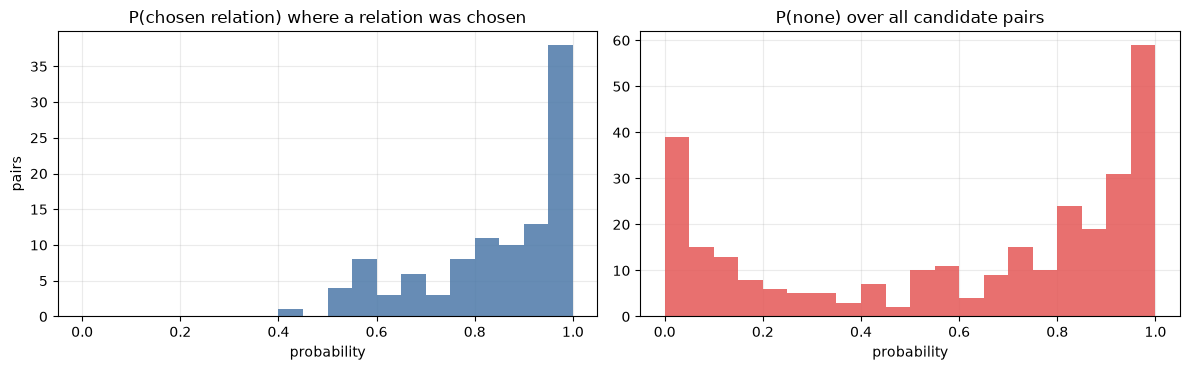

least confident selections:


,doc_id,head,relation,tail,head_type,tail_type,p,conf,p_none
186,d08,fuel,impacts,Vantage Energy Partners,commodity,company,0.43,0.15,0.34
149,d06,Northwind Logistics,operates_in,Seattle,company,geography,0.50,0.01,0.50
54,d03,supply disruptions,impacts,Torrent Microsystems,risk_factor,security,0.50,0.01,0.50
180,d07,Cascade Freight transaction,impacts,Western District of Washington,business_event,geography,0.50,0.00,0.50
105,d06,antitrust inquiry,impacts,Halcyon Semiconductor,business_event,company,0.54,0.08,0.46
179,d07,Cascade Freight transaction,impacts,Northwind Logistics Inc.,business_event,company,0.56,0.11,0.44
86,d04,Diesel,impacts,adjusted operating margin,commodity,financial_metric,0.57,0.13,0.43
27,d01,Priya Raman,participant_in,acquisition,person,business_event,0.57,0.14,0.43


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
axes[0].hist(picked["p"], bins=20, range=(0, 1), color="#4C78A8", alpha=0.85)
axes[0].set_title("P(chosen relation) where a relation was chosen")
axes[0].set_xlabel("probability"); axes[0].set_ylabel("pairs")
axes[1].hist(PK["p_none"], bins=20, range=(0, 1), color="#E45756", alpha=0.85)
axes[1].set_title("P(none) over all candidate pairs")
axes[1].set_xlabel("probability")
for ax in axes:
    ax.grid(alpha=0.25); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

print("least confident selections:")
display(picked.sort_values("p").head(8))

### 2.1 Scored against the gold triples

Four systems from one extraction pass and one selection pass, all through the same resolution:
GLiNER's edges; the selected edges at `P(relation) ≥ 0.5`; their union; their intersection. The union is
the interesting row — it says whether selection finds things joint decoding missed — and the intersection
is the check that the two agree on something.

In [7]:
def union_graphs(a_graphs, b_graphs):
    out = []
    for ga, gb in zip(a_graphs, b_graphs):
        seen = {(e.head, e.type, e.tail) for e in ga.edges}
        edges = list(ga.edges) + [e for e in gb.edges if (e.head, e.type, e.tail) not in seen]
        out.append(DocGraph(doc_id=ga.doc_id, text=ga.text, mentions=list(ga.mentions),
                            edges=edges, feasible=ga.feasible, meta=dict(ga.meta)))
    return out

def intersect_graphs(a_graphs, b_graphs):
    out = []
    for ga, gb in zip(a_graphs, b_graphs):
        keys = {(gb.mention(e.head).text, e.type, gb.mention(e.tail).text) for e in gb.edges}
        edges = [e for e in ga.edges if (ga.mention(e.head).text, e.type, ga.mention(e.tail).text) in keys]
        out.append(DocGraph(doc_id=ga.doc_id, text=ga.text, mentions=list(ga.mentions),
                            edges=edges, feasible=ga.feasible, meta=dict(ga.meta)))
    return out

sel_graphs = kts.picks_to_graphs(graphs, picks, min_prob=0.5)

systems = {
    "GLiNER2.5 joint decoding":     graphs,
    "TypeSafe selection (p >= .5)": sel_graphs,
    "union":                        union_graphs(graphs, sel_graphs),
    "intersection":                 intersect_graphs(graphs, sel_graphs),
}
results = {name: score(g, name)[0] for name, g in systems.items()}
display(comparison_table(results))
print(f"edges: " + ", ".join(f"{n} {sum(len(g.edges) for g in gs)}" for n, gs in systems.items()))

,policy,predicted,gold,matched,precision,recall,f1
system,,,,,,,
GLiNER2.5 joint decoding,normalised + aliases,68,47,19,0.279,0.404,0.330
union,normalised + aliases,123,47,25,0.203,0.532,0.294
TypeSafe selection (p >= .5),normalised + aliases,89,47,19,0.213,0.404,0.279
intersection,normalised + aliases,27,47,8,0.296,0.170,0.216


edges: GLiNER2.5 joint decoding 170, TypeSafe selection (p >= .5) 104, union 249, intersection 67


**Same recall, half the precision, and they are not finding the same things.** Selection at `p ≥ 0.5`
recovers 19 of 47 gold triples — exactly GLiNER's 19 — from 89 predicted triples against GLiNER's 68. The
union recovers **25**: recall 0.404 → 0.532. The intersection recovers 8, which says the two systems agree
on less than half of what either gets right, and that agreement barely buys precision (0.296).

Look at where the selector spends its errors before judging it. 105 of 295 pairs got a relation, and 21 of
those were `impacts` — the ontology's most permissive relation, with six legal tail types — mostly at
`p` just over 0.5. A `Choice` with a `none` option said `none` to 64% of the candidates, which is the
option doing its job; the residue is the relations it was least sure of, and the sweep below shows what
happens when those are held to a higher standard.

### 2.2 The whole frontier, from one pass

`min_prob` is a threshold on stored probabilities, so sweeping it costs nothing. The curve is what the
selection pass bought; the star is where joint decoding sits.

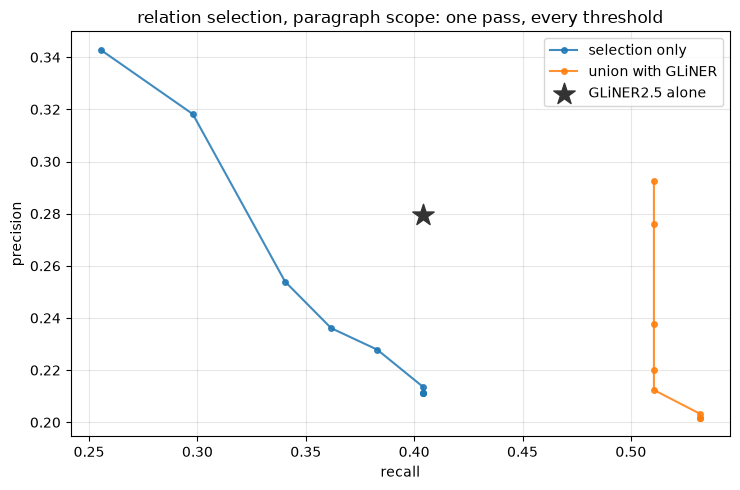

recall                               f1                  
system   selection only union with GLiNER selection only union with GLiNER
min_prob                                                                  
0.20              0.404             0.532          0.277             0.292
0.30              0.404             0.532          0.277             0.292
0.40              0.404             0.532          0.277             0.292
0.50              0.404             0.532          0.279             0.294
0.60              0.383             0.511          0.286             0.300
0.70              0.362             0.511          0.286             0.308
0.80              0.340             0.511          0.291             0.324
0.90              0.298             0.511          0.308             0.358
0.95              0.255             0.511          0.293             0.372

In [8]:
sweep = []
for tau in [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95]:
    sg = kts.picks_to_graphs(graphs, picks, min_prob=tau)
    for label, gs in [("selection only", sg), ("union with GLiNER", union_graphs(graphs, sg))]:
        s, tri = score(gs, label)
        sweep.append({"min_prob": tau, "system": label, "triples": len(tri),
                      "precision": s.precision, "recall": s.recall, "f1": s.f1})
S = pd.DataFrame(sweep)

fig, ax = plt.subplots(figsize=(7.5, 5))
for label, grp in S.groupby("system", sort=False):
    ax.plot(grp["recall"], grp["precision"], "o-", label=label, markersize=4, alpha=0.85)
ax.scatter([base_score.recall], [base_score.precision], marker="*", s=260, color="#333", zorder=5,
           label="GLiNER2.5 alone")
ax.set_xlabel("recall"); ax.set_ylabel("precision"); ax.grid(alpha=0.3)
ax.set_title("relation selection, paragraph scope: one pass, every threshold")
ax.legend(); plt.tight_layout(); plt.show()

display(S.pivot_table(index="min_prob", columns="system", values=["recall", "f1"], sort=False).round(3))

### 2.3 What selection found that decoding did not — and the reverse

Attribution, not just totals. Which gold triples does each system recover, and where do they disagree?

In [9]:
gold_hits = {}
for name, gs in systems.items():
    s, tri = score(gs, name)
    gold_hits[name] = {tuple(gold) for _pred, gold in s.matched}   # matched = (predicted, gold) pairs

only_sel = gold_hits["TypeSafe selection (p >= .5)"] - gold_hits["GLiNER2.5 joint decoding"]
only_gli = gold_hits["GLiNER2.5 joint decoding"] - gold_hits["TypeSafe selection (p >= .5)"]
both = gold_hits["GLiNER2.5 joint decoding"] & gold_hits["TypeSafe selection (p >= .5)"]
print(f"gold triples recovered by both: {len(both)}   only by selection: {len(only_sel)}   "
      f"only by joint decoding: {len(only_gli)}\n")
print("recovered only by selection:")
for t in sorted(only_sel): print("   ", t)
print("\nrecovered only by joint decoding:")
for t in sorted(only_gli): print("   ", t)

gold triples recovered by both: 13   only by selection: 6   only by joint decoding: 6

recovered only by selection:
    ('Halcyon Semiconductor Corporation', 'subject_to', 'European Commission')
    ('Northwind Logistics Inc.', 'operates_in', 'Seattle')
    ('Northwind Logistics Inc.', 'subject_to', 'Securities and Exchange Commission')
    ('Northwind Logistics Inc.', 'subject_to', 'Surface Transportation Board')
    ('Torrent Microsystems', 'supplies', 'Northwind Logistics Inc.')
    ('Vantage Energy Partners', 'supplies', 'Northwind Logistics Inc.')

recovered only by joint decoding:
    ('Halcyon Semiconductor Corporation', 'produces', 'automotive-grade microcontrollers')
    ('Halcyon Semiconductor Corporation', 'produces', 'power management controllers')
    ('Halcyon Semiconductor Corporation', 'produces', 'radar front-ends')
    ('Northwind Logistics Inc.', 'operates_in', 'European Union')
    ('Northwind Logistics Inc.', 'partners_with', 'Halcyon Semiconductor Corporation')
  

In [10]:
# GLiNER edges the selector answered `none` to -- the disagreements in the other direction.
gliner_keys = {(g.doc_id, g.mention(e.head).text, e.type, g.mention(e.tail).text): e.confidence
               for g in graphs for e in g.edges}
pick_by_key = {(p.doc_id, p.head_text, p.tail_text): p for p in picks}

rows = []
for (doc_id, h, rel, t), conf in gliner_keys.items():
    p = pick_by_key.get((doc_id, h, t))
    if p is None:
        continue
    if p.relation != rel:
        rows.append({"doc_id": doc_id, "head": h, "gliner": rel, "gliner conf": round(conf, 2),
                     "typesafe": p.relation, "p": round(p.p_relation, 2),
                     "p_none": round(p.probabilities.get(kts.NO_RELATION, 0), 2), "tail": t})
D = pd.DataFrame(rows)
print(f"GLiNER edges whose pair the selector judged: {sum(1 for k in gliner_keys if (k[0], k[1], k[3]) in pick_by_key)}")
print(f"  ... where it chose a different relation or none: {len(D)}")
print(D["typesafe"].value_counts().to_string() if len(D) else "")
display(D.sort_values("gliner conf", ascending=False).head(14))

GLiNER edges whose pair the selector judged: 41
  ... where it chose a different relation or none: 11
typesafe
none             7
acquires         2
subsidiary_of    1
supplies         1


,doc_id,head,gliner,gliner conf,typesafe,p,p_none,tail
8,d08,Vantage Energy Partners,partners_with,0.97,supplies,1.00,0.00,Northwind Logistics Inc.
7,d07,Cascade Freight Systems,subsidiary_of,0.91,none,0.00,0.51,Northwind Logistics Inc.
4,d07,Priya Raman,officer_of,0.89,none,0.00,0.87,Northwind Logistics Inc.
5,d07,Marcus Webb,officer_of,0.82,none,0.00,0.88,Northwind Logistics Inc.
9,d08,Northwind Logistics,reports_metric,0.75,none,0.00,0.98,total contract value
1,d01,Northwind Logistics,partners_with,0.58,acquires,1.00,0.00,Cascade Freight Systems
0,d01,Cascade Freight Systems,competes_with,0.53,subsidiary_of,0.75,0.23,Northwind Logistics
2,d01,Northwind Logistics Inc.,partners_with,0.53,acquires,1.00,0.00,Cascade Freight Systems
6,d07,Northwind Logistics Inc.,reports_metric,0.52,none,0.00,0.99,revenue
3,d05,Torrent Microsystems,faces_risk,0.39,none,0.00,0.58,price


**When they disagree on a pair both saw, the selector is often correcting the decoder.** Three of the
eleven disagreements are relabels at high confidence, and all three are gold-correct: GLiNER's
`partners_with(Northwind, Cascade)` at 0.58 becomes `acquires` at 1.00; `partners_with(Vantage, Northwind)`
at 0.97 becomes `supplies` at 1.00; `competes_with(Cascade, Northwind)` at 0.53 becomes `subsidiary_of` at
0.75. A joint decoder that has committed to *some* relation between two entities is not choosing among
the alternatives the way a `Choice` over exactly those alternatives does.

The seven `none`s are the other direction, and two of them are misses: `subsidiary_of(Cascade, Northwind)`
in d07 at `p_none` 0.51 — a coin flip — and both `officer_of` edges in d07 at 0.87. That document is an
8-K that names the officers without stating their roles in the same paragraph, and the selector, unlike
the decoder, was only shown the paragraph.

And the six gold triples only joint decoding found are all cross-paragraph pairs — `produces` from a
product list three paragraphs below the company, `partners_with` from a lede to a later paragraph. Not
things the selector judged wrongly; things it was never asked about. §4 asks about them.

---

## 3. Select, then gate

Notebook 10's assertion gate removed 56 of GLiNER's 170 edges at zero recall cost. The selected edges are
new candidates the gate has never seen, so run it: two more questions per edge — *does the document connect
these two things*, and *how does it present the claim*.

In [11]:
before = ts.n_calls + ts.n_cached
judgments = kts.judge_edges(ts, sel_graphs, ONTO, max_questions=24)
n_gate_req = ts.n_calls + ts.n_cached - before

J = pd.DataFrame([j.as_record() for j in judgments])
print(f"{len(J)} selected edges judged in {n_gate_req} requests")
print(J["status"].value_counts().to_string())
print(f"\nkept: {int(J['keep'].sum())} / {len(J)}")

KEEP = {(j.doc_id, j.head, j.relation, j.tail) for j in judgments if j.keep}

def gate(doc_graphs, keep):
    out = []
    for g in doc_graphs:
        kept = [e for e in g.edges
                if (g.doc_id, g.mention(e.head).text, e.type, g.mention(e.tail).text) in keep]
        out.append(DocGraph(doc_id=g.doc_id, text=g.text, mentions=list(g.mentions),
                            edges=kept, feasible=g.feasible, meta=dict(g.meta)))
    return out

gated_sel = gate(sel_graphs, KEEP)

104 selected edges judged in 13 requests
status
asserted           86
hypothetical       10
forward_looking     8

kept: 86 / 104


In [12]:
# Notebook 10's gate on GLiNER's edges, replayed from the same cache, so the
# union row compares like with like.
gliner_judgments = kts.judge_edges(ts, graphs, ONTO, max_questions=24)
gated_gliner = gate(graphs, {(j.doc_id, j.head, j.relation, j.tail) for j in gliner_judgments if j.keep})

final = {
    "GLiNER2.5":                          graphs,
    "GLiNER2.5 + gate  (notebook 10)":    gated_gliner,
    "selection":                          sel_graphs,
    "selection + gate":                   gated_sel,
    "union, both gated":                  union_graphs(gated_gliner, gated_sel),
}
final_scores = {name: score(g, name)[0] for name, g in final.items()}
display(comparison_table(final_scores))

,policy,predicted,gold,matched,precision,recall,f1
system,,,,,,,
GLiNER2.5 + gate (notebook 10),normalised + aliases,47,47,19,0.404,0.404,0.404
"union, both gated",normalised + aliases,93,47,24,0.258,0.511,0.343
GLiNER2.5,normalised + aliases,68,47,19,0.279,0.404,0.330
selection,normalised + aliases,89,47,19,0.213,0.404,0.279
selection + gate,normalised + aliases,77,47,17,0.221,0.362,0.274


The gate does not help the selector the way it helped the decoder — and the sweep in §2.2 said why:
the selector's damage is at *low* confidence, not in hedged claims. So combine the two systems the way the
sweep suggests: the decoder's edges gated, plus only the selector's confident edges, gated.

In [13]:
def best_of_both(gliner_gated, picks_, keep, taus):
    rows = {}
    for tau in taus:
        sel = gate(kts.picks_to_graphs(graphs, picks_, min_prob=tau), keep)
        rows[f"GLiNER + gate  ∪  selection (p >= {tau}) + gate"] = union_graphs(gliner_gated, sel)
    return rows

combo = best_of_both(gated_gliner, picks, KEEP, (0.5, 0.7, 0.9, 0.95))
combo_scores = {name: score(g, name)[0] for name, g in combo.items()}
display(comparison_table({"GLiNER2.5 + gate  (notebook 10)": final_scores["GLiNER2.5 + gate  (notebook 10)"],
                          **combo_scores}))

,policy,predicted,gold,matched,precision,recall,f1
system,,,,,,,
GLiNER + gate ∪ selection (p >= 0.95) + gate,normalised + aliases,58,47,23,0.397,0.489,0.438
GLiNER + gate ∪ selection (p >= 0.9) + gate,normalised + aliases,62,47,23,0.371,0.489,0.422
GLiNER2.5 + gate (notebook 10),normalised + aliases,47,47,19,0.404,0.404,0.404
GLiNER + gate ∪ selection (p >= 0.7) + gate,normalised + aliases,81,47,23,0.284,0.489,0.359
GLiNER + gate ∪ selection (p >= 0.5) + gate,normalised + aliases,93,47,24,0.258,0.511,0.343


**The gate is the wrong tool for the selector's errors, and confidence is the right one.** On GLiNER's
edges the gate removed 56 with no recall cost; on the selector's it removes 18, costs two gold triples
(recall 0.404 → 0.362), and buys 0.008 of precision. The selector's spurious edges are not hedged claims —
they are plainly stated non-relations chosen at low probability, and the `status` question has nothing to
say about them.

Filtering the selector by its own probability does what the gate could not. Add only the selections at
`p ≥ 0.95` to GLiNER's gated edges and F1 goes **0.404 → 0.438** — recall 0.489, precision 0.397, four
more gold triples than notebook 10's best for a loss of 0.007 precision. The whole frontier came from one
inference pass; no threshold cost a request.

---

## 4. Document scope

Every legal ordered pair anywhere in the document: about three and a half times the candidates, for pairs
joint decoding could never have connected. Whether that is recall or noise is the measurement.

In [14]:
before = ts.n_calls + ts.n_cached
t0 = time.perf_counter()
picks_doc = kts.select_relations(ts, graphs, ONTO, scope="document", max_questions=24)
doc_s = time.perf_counter() - t0
n_doc_req = ts.n_calls + ts.n_cached - before

PD_ = pd.DataFrame([p.as_record() for p in picks_doc])
picked_doc = PD_[PD_["relation"] != kts.NO_RELATION]
print(f"{len(PD_)} candidate pairs in {n_doc_req} requests ({doc_s:.1f}s); "
      f"relation selected for {len(picked_doc)} ({len(picked_doc) / len(PD_):.0%})")

sel_doc = kts.picks_to_graphs(graphs, picks_doc, min_prob=0.5)
scope_rows = {
    "paragraph scope, selection":          sel_graphs,
    "paragraph scope, union with GLiNER":  union_graphs(graphs, sel_graphs),
    "document scope, selection":           sel_doc,
    "document scope, union with GLiNER":   union_graphs(graphs, sel_doc),
}
scope_scores = {name: score(g, name)[0] for name, g in scope_rows.items()}
display(comparison_table(scope_scores))

para_hits = {tuple(g) for _p, g in scope_scores["paragraph scope, selection"].matched}
doc_hits = {tuple(g) for _p, g in scope_scores["document scope, selection"].matched}
print(f"\ngold triples found at document scope but not paragraph scope: {len(doc_hits - para_hits)}")
for t in sorted(doc_hits - para_hits): print("   ", t)
print(f"requests: paragraph {n_req}, document {n_doc_req}")

1028 candidate pairs in 47 requests (0.0s); relation selected for 300 (29%)


,policy,predicted,gold,matched,precision,recall,f1
system,,,,,,,
"paragraph scope, union with GLiNER",normalised + aliases,123,47,25,0.203,0.532,0.294
"paragraph scope, selection",normalised + aliases,89,47,19,0.213,0.404,0.279
"document scope, selection",normalised + aliases,166,47,28,0.169,0.596,0.263
"document scope, union with GLiNER",normalised + aliases,184,47,28,0.152,0.596,0.242



gold triples found at document scope but not paragraph scope: 10
    ('Halcyon Semiconductor Corporation', 'operates_in', 'Dresden')
    ('Halcyon Semiconductor Corporation', 'produces', 'automotive-grade microcontrollers')
    ('Halcyon Semiconductor Corporation', 'produces', 'power management controllers')
    ('Halcyon Semiconductor Corporation', 'produces', 'radar front-ends')
    ('Northwind Logistics Inc.', 'has_stake_in', 'Meridian Rail Group')
    ('Northwind Logistics Inc.', 'operates_in', 'European Union')
    ('Northwind Logistics Inc.', 'partners_with', 'Halcyon Semiconductor Corporation')
    ('Northwind Logistics Inc.', 'partners_with', 'Meridian Rail Group')
    ('Northwind Logistics Inc.', 'supplies', 'Halcyon Semiconductor Corporation')
    ('Vantage Energy Partners', 'supplies', 'Halcyon Semiconductor Corporation')
requests: paragraph 16, document 47


In [15]:
before = ts.n_calls + ts.n_cached
judgments_doc = kts.judge_edges(ts, sel_doc, ONTO, max_questions=24)
n_doc_gate_req = ts.n_calls + ts.n_cached - before
KEEP_DOC = {(j.doc_id, j.head, j.relation, j.tail) for j in judgments_doc if j.keep}
print(f"{len(judgments_doc)} document-scope selected edges judged in {n_doc_gate_req} requests; "
      f"kept {len(KEEP_DOC)}")

combo_doc = best_of_both(gated_gliner, picks_doc, KEEP_DOC, (0.5, 0.7, 0.9, 0.95))
combo_doc_scores = {name.replace("selection", "doc-scope selection"): score(g, name)[0]
                    for name, g in combo_doc.items()}
display(comparison_table({"GLiNER2.5 + gate  (notebook 10)": final_scores["GLiNER2.5 + gate  (notebook 10)"],
                          **combo_doc_scores}))

297 document-scope selected edges judged in 28 requests; kept 233


,policy,predicted,gold,matched,precision,recall,f1
system,,,,,,,
GLiNER + gate ∪ doc-scope selection (p >= 0.95) + gate,normalised + aliases,66,47,25,0.379,0.532,0.442
GLiNER + gate ∪ doc-scope selection (p >= 0.9) + gate,normalised + aliases,80,47,27,0.338,0.574,0.425
GLiNER2.5 + gate (notebook 10),normalised + aliases,47,47,19,0.404,0.404,0.404
GLiNER + gate ∪ doc-scope selection (p >= 0.7) + gate,normalised + aliases,110,47,27,0.245,0.574,0.344
GLiNER + gate ∪ doc-scope selection (p >= 0.5) + gate,normalised + aliases,130,47,28,0.215,0.596,0.316


**Document scope is where the selector finds what the decoder found, and then some.** 1,028 candidates,
300 relations selected, and recall **0.596** — 28 of 47 gold triples, the most any system in this repo has
recovered from this corpus — at precision 0.169. The ten triples it adds over paragraph scope include all
six the decoder had to itself: `produces` × 3, both `partners_with`, `operates_in` EU. Given the same reach,
selection sees what joint decoding sees.

Gated and filtered at `p ≥ 0.95`, and unioned with GLiNER's gated edges, it is the best system measured
here: **F1 0.442, recall 0.532, precision 0.379**. At `p ≥ 0.9` recall reaches 0.574 for F1 0.425. The
cost is 47 requests for selection and 28 for the gate — against the decoder's zero, and against
paragraph scope's 16 + 13 for F1 0.438. Three times the requests for four thousandths of F1 and four
points of recall; whether that is worth it is a question about what the graph is for, and the frontier
is there to answer it.

---

## 5. What it cost

In [16]:
stats = ts.stats()
display(pd.Series(stats).to_frame("value"))
print(f"\nselection, paragraph scope : {n_req} requests for {len(PK)} pairs")
print(f"gate on selected edges     : {n_gate_req} requests for {len(J)} edges")
print(f"selection, document scope  : {n_doc_req} requests for {len(PD_)} pairs")
print(f"gate on doc-scope edges    : {n_doc_gate_req} requests for {len(judgments_doc)} edges")
print(f"joint decoding             : 0 requests, {gliner_s:.1f}s on a CPU")

,value
requests_live,0.0
requests_cached,122.0
questions,2465.0
questions_per_request,20.2
input_tokens_billed,0.0
output_tokens_billed,0.0
input_tokens_observed,458065.0
output_tokens_observed,92653.0
ms_spent,0.0
ms_per_request_observed,182.4



selection, paragraph scope : 16 requests for 295 pairs
gate on selected edges     : 13 requests for 104 edges
selection, document scope  : 47 requests for 1028 pairs
gate on doc-scope edges    : 28 requests for 297 edges
joint decoding             : 0 requests, 14.7s on a CPU


---

## 6. Findings

*Measured on this repo's corpus, not asserted. Reproducible from `output/typesafe_cache/`.*

In [17]:
print("=" * 78)
print("SUMMARY".center(78))
print("=" * 78)
for name, s in final_scores.items():
    print(f"  {name:<34} P {s.precision:.3f}  R {s.recall:.3f}  F1 {s.f1:.3f}")
print()
for name, s in scope_scores.items():
    print(f"  {name:<34} P {s.precision:.3f}  R {s.recall:.3f}  F1 {s.f1:.3f}")
print()
best_p = max(combo_scores.items(), key=lambda kv: kv[1].f1)
best_d = max(combo_doc_scores.items(), key=lambda kv: kv[1].f1)
for name, s_ in (best_p, best_d):
    print(f"  {name:<58} P {s_.precision:.3f}  R {s_.recall:.3f}  F1 {s_.f1:.3f}")
print()
print(f"  candidate pairs   paragraph {len(PK)}  document {len(PD_)}")
print(f"  requests          paragraph {n_req}  gate {n_gate_req}  document {n_doc_req}  doc gate {n_doc_gate_req}")
print(f"  gold only via selection (paragraph): {len(only_sel)}   only via decoding: {len(only_gli)}")
print("=" * 78)

                                   SUMMARY                                    
  GLiNER2.5                          P 0.279  R 0.404  F1 0.330
  GLiNER2.5 + gate  (notebook 10)    P 0.404  R 0.404  F1 0.404
  selection                          P 0.213  R 0.404  F1 0.279
  selection + gate                   P 0.221  R 0.362  F1 0.274
  union, both gated                  P 0.258  R 0.511  F1 0.343

  paragraph scope, selection         P 0.213  R 0.404  F1 0.279
  paragraph scope, union with GLiNER P 0.203  R 0.532  F1 0.294
  document scope, selection          P 0.169  R 0.596  F1 0.263
  document scope, union with GLiNER  P 0.152  R 0.596  F1 0.242

  GLiNER + gate  ∪  selection (p >= 0.95) + gate             P 0.397  R 0.489  F1 0.438
  GLiNER + gate  ∪  doc-scope selection (p >= 0.95) + gate   P 0.379  R 0.532  F1 0.442

  candidate pairs   paragraph 295  document 1028
  requests          paragraph 16  gate 13  document 47  doc gate 28
  gold only via selection (paragraph): 6   only v

### Selection and decoding find different relations, and the union is the point

At paragraph scope both recover 19 gold triples; only 13 are the same 13. Six are found only by the
selector — three `subject_to` edges to regulators, two `supplies`, one `operates_in` — and six only by the
decoder, every one of them a cross-paragraph pair the paragraph-scoped selector never saw. The union
recovers 25. Neither system subsumes the other, and the reason is structural: joint decoding commits to
one graph over the whole document, selection asks an independent question about each pair.

### Selection alone is not a better extractor

Same recall as GLiNER, at half the precision: 0.213 against 0.279, at `p ≥ 0.5`. A `Choice` answered
`none` to 64% of candidates (71% at document scope), and most of the damage is in what it let through at
low probability — `impacts`, the ontology's most permissive relation, accounts for a fifth of the picks.
The `none` option is load-bearing; without it every candidate pair would be an edge.

### The selector's errors are confidence errors, not modality errors — so gate by probability

Notebook 10's assertion gate removed 56 GLiNER edges at zero recall cost. Applied to the selector's edges
it costs two gold triples and buys 0.008 precision, because the selector's spurious edges are not hedged
claims, they are wrong relations chosen at 0.5. Its own probability is the filter: at `p ≥ 0.95`, added to
GLiNER's gated edges, F1 goes **0.404 → 0.438** at paragraph scope and **0.442** at document scope, with
recall 0.532. That is the best F1 any configuration in this repo has produced on this corpus, from one
selection pass and a threshold.

### The selector corrects the decoder on pairs both saw

Three high-confidence relabels, all gold-correct: `partners_with` → `acquires` (1.00), `partners_with` →
`supplies` (1.00), `competes_with` → `subsidiary_of` (0.75). A joint decoder that has committed to *a*
relation between two entities has not necessarily chosen among the alternatives; a `Choice` over exactly
those alternatives, with the ontology's descriptions as criteria, has.

### 130 of 170 decoder edges cross a paragraph — measure the scope, do not assume it

The first draft of this notebook asserted the opposite, from a probe with a bug in it. The notebook's own
check said 130, and it reframes the whole comparison: paragraph scope is a handicap, document scope is the
fair fight, and it costs three times the requests (47 against 16). Document scope alone reaches recall
0.596, the highest here; confidence-filtered and unioned it reaches F1 0.442. Whether four points of
recall are worth 3× the requests is what the frontier is for.

### Where this leaves the division of labour

Extract locally and exhaustively; enumerate candidates in code; let the judgment model *select* from an
answer set the ontology wrote; keep only what it is sure of; keep everything it said as data. The decoder
is still the thing that finds entities and — across paragraphs — most relations. The selector is the
thing that, given a pair, knows which relation it is. Neither replaces the other, and the measured best
system uses both.